In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scipy.optimize as opt
import itertools
import random
import re
import os
import pickle
from library2_utils.color_scheme import cell_line_colors, cell_line_symbols
from library2_utils.design_utilities import tsi

# set the font size
plt.rcParams.update({'font.size': 7})
# set Helvetica globally
plt.rcParams['font.family'] = 'Helvetica'

cell_lines_subset = ["HEK293T", "HeLa", "SKNSH", "MCF7", "HUH7", "A549"]
cell_lines_rest = ["HaCaT", "JEG3", "Tera1", "PC3"]
cell_lines_measured = cell_lines_subset + cell_lines_rest

output_folder = "../outputs/12_highly_expressed_fitting"
# create it if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    
plot_folder = "../plots/12_highly_expressed_fitting"
# create it if it doesn't exist
if not os.path.exists(plot_folder):
    os.makedirs(plot_folder)

Here, we see how many miRNAs we need to fit the scaling factor

In [70]:
data_dir_input = "../measured_data/2_normalized_log10"

# get the name of all files in "reference" folder
reference_files = os.listdir(data_dir_input)

# read them into a dictionary
reference_dict = {}
for reference_file in reference_files:
    if reference_file.endswith(".csv"):
        reference_dict[reference_file.split('.')[0]] = pd.read_csv(os.path.join(data_dir_input, reference_file), index_col=0)

In [71]:
# get only the high confidence microRNAs in mirbase
mirbase = pd.read_csv("../microrna_data/mirbase_extended.csv", index_col=0)
mirbase_high_confidence = mirbase[mirbase["confidence"] == "high"]

In [72]:
df_alles = pd.read_csv("../microrna_data/2_output/Alles2019_conormalized.csv", index_col=0)
df_alles = np.log10(df_alles)

df_keller = pd.read_csv('../microrna_data/2_output/Keller2023_conormalized.csv', index_col=0)
df_keller = np.log10(df_keller)


used_mirna_data = df_alles
used_mirna_name = "Alles2019"

In [73]:
# ADD EXPRESSION DATA TO THE DATAFRAMES
# get all dfs that contain "single" in their key
single_dfs = {key: reference_dict[key].copy() for key in reference_dict.keys() if "single" in key}

for key, df in single_dfs.items():
    # add miRNA expression data
    # this is done by matching the column "miRNA1" in the df with the column "miRNA" in the mirna_expression_df
    # not all values are present in the mirna_expression_df, so we have to match them
    
    df.set_index("miRNA1", inplace=True)
    # remove all columns that are not 3UTR
    df = df.filter(regex='(3UTR)')
    
    # check which cell lines are in the expression_df
    for column in df.columns:
        if column.split("_")[0] not in used_mirna_data.columns:
           df = df.drop(column, axis=1)

    # restrict to microRNAs that are present in the expression_df
    df = df.loc[df.index.intersection(used_mirna_data.index)]

    # get the current list of cell lines:
    cell_lines = [column.split("_")[0] for column in df.columns]
    for cell_line in cell_lines:
        df.loc[:, f"{cell_line}_exp"] = used_mirna_data.loc[df.index, cell_line]

    # drop NaN values
    df.dropna(inplace=True)

    single_dfs[key] = df

In [74]:
# Look only at high confidence mirnas OR those in mirgenedb
# high confidence
measured_single = single_dfs["1_mirna_full_single_high_conf"]
# add mirgenedb
measured_single = pd.concat([measured_single, single_dfs["2_mirna_full_single_low_conf_mirgenedb"]], axis=0)

# split into knockdown and expression
# filter to columns that contain "_3UTR"
df_knockdown = measured_single.filter(regex='_3UTR')
# rename columns to drop everthing except the cell line name
df_knockdown.columns = [col.split("_")[0] for col in df_knockdown.columns]

# filter to columns that contain "exp"
df_expression = measured_single.filter(regex='exp')
# rename columns to drop the "_exp"
df_expression.columns = [col.split("_")[0] for col in df_expression.columns]

In [75]:
# load the crosstalk dict
input_folder = "../outputs/5_mutations"

with open(f"{input_folder}/5.7_crosstalk_filter_dict.pkl", "rb") as f:
    crosstalk_filter_dict = pickle.load(f)

# make a list of allowed mirnas per cell line (crosstalk)
allowed_mirnas_all = {}
for cell_line in cell_lines_measured:
    allowed_mirnas = []
    crosstalk_dict = crosstalk_filter_dict[cell_line]
    allowed_mirnas_all[cell_line] = list(df_knockdown.index.difference(crosstalk_dict))

In [76]:
df_knockdown_filter_congruence = df_knockdown.copy()

# filter to allowed mirnas by removing crosstalk
for cell_line in cell_lines_measured:
    df_knockdown_filter_congruence[cell_line] = df_knockdown_filter_congruence.loc[allowed_mirnas_all[cell_line], cell_line]
    
# remove "hsa-miR-3613-3p"
df_knockdown_filter_congruence = df_knockdown_filter_congruence[df_knockdown_filter_congruence.index != "hsa-miR-3613-3p"]

# calculate the geometric mean
mirna_ex_geometric_mean = (df_alles.loc[df_alles.index, cell_lines_measured] + df_keller.loc[df_alles.index, cell_lines_measured])/2.0

# # remove those where either of the two is too far from the mean
# congruent_dataset = True
# df_alles_filter = df_alles[cell_lines_measured].copy()
# df_keller_filter = df_keller[cell_lines_measured].copy()
# # set all values smaller than 2 to 2
# df_alles_filter[df_alles_filter < 2.5] = 2.5
# df_keller_filter[df_keller_filter < 2.5] = 2.5

# common_index = df_alles_filter.index.intersection(df_keller_filter.index)
# df_alles_filter = df_alles_filter.loc[common_index, :]
# df_keller_filter = df_keller_filter.loc[common_index, :]

# diff_df = abs(df_alles_filter - df_keller_filter)
# diff_df[diff_df > 1] = np.nan
# diff_df = diff_df.loc[df_knockdown_filter_congruence.index, :]

# for cell_line in cell_lines_measured:
#     diff_df_cell_line = diff_df[cell_line]
#     df_knockdown_filter_congruence.loc[diff_df_cell_line[(diff_df_cell_line.isna() == True)].index, cell_line] = np.nan

In [77]:
df_expression_filter_congruence = mirna_ex_geometric_mean.loc[df_knockdown_filter_congruence.index, cell_lines_measured]
for cell_line in cell_lines_measured:
    valid_mirnas = df_knockdown_filter_congruence[cell_line].dropna().index
    df_expression_filter_congruence.loc[~(df_expression_filter_congruence.index.isin(valid_mirnas)), cell_line] = np.nan

In [78]:
def hill_func_log_scales(x_data, dataset_indices, c1=3, c2=5, *scales):
    """This is a hill function for a set of microRNA expression values that can be scaled individually.
    
    The expression is assumed to be normalized to one.
    The microRNA data is assumed to be log10.
    The return value is also log10."""
    c1 = 10**c1
    c2 = 10**c2
    results = []

    for i, scale in enumerate(scales):
        mask = (dataset_indices == i)
        x = x_data[mask] + scale
        x = 10**x
        result = (1 / (1 + x / c1)) * (1 + x / c2)
        results.append( np.log10( result ))
    return np.concatenate(results)

def hill_func_log_regular(x, c1=3, c2=4.5):
    """The expression is assumed to be normalized to one.
    The microRNA data is assumed to be log10.
    The return value is also log10."""
    x = 10**x
    c1 = 10**c1
    c2 = 10**c2
    
    result = (1 / (1 + x / c1)) * (1 + x / c2)
    return np.log10(result)

In [79]:
# redo the fitting
x_data = []
y_data = []
dataset_indices = []
for i, cell_line in enumerate(cell_lines_measured):
    ex_df = df_expression_filter_congruence[cell_line].dropna().values
    knock_df = df_knockdown_filter_congruence[cell_line].dropna().values
    x_data.append(ex_df)
    y_data.append(knock_df)
    dataset_indices.append([i] * len(ex_df))

x_data = np.concatenate(x_data)
y_data = np.concatenate(y_data)
dataset_indices = np.concatenate(dataset_indices)

# set bounds and initial guesses for non-scale fitting parameters
p0 = [3, 10]
num_params = len(p0)
bounds = ([1, 9.99], [10, 10.01])

# Guess initial scale values for all datasets
scale_guesses = [0 for _ in range(len(cell_lines_measured))]
scale_bounds_min = [-2 for _ in range(len(cell_lines_measured))]
scale_bounds_max = [2 for _ in range(len(cell_lines_measured))]

# set scale for HEK293T to 0
scale_bounds_min[0] = -0.001
scale_bounds_max[0] = 0.001

# set up parameters
p0_scale = p0 + scale_guesses
bounds_scale = (bounds[0]+scale_bounds_min, bounds[1]+scale_bounds_max)

popt_scales, pcov = popt_scales_filter, pcov = opt.curve_fit(
    lambda x, *params: hill_func_log_scales(x, dataset_indices, *params),
    x_data,
    y_data,
    p0=p0_scale,
    bounds=bounds_scale,
    maxfev=5000
)

scales = list(popt_scales[num_params:])
hill_params = popt_scales[:num_params]
hill_params

array([3.66349729, 9.99      ])

In [80]:
scale_dict = {cell_line: scale for cell_line, scale in zip(cell_lines_measured, scales)}

In [81]:
scale_dict

{'HEK293T': -0.00010939061796635033,
 'HeLa': 0.11520663986766998,
 'SKNSH': -0.1291336730048831,
 'MCF7': -0.08831354614371582,
 'HUH7': -0.31256146991463385,
 'A549': 0.13342479244882985,
 'HaCaT': 0.07811191350222553,
 'JEG3': -0.14991947995600619,
 'Tera1': 0.0015940628577813143,
 'PC3': 0.29382784042514015}

In [82]:
# calculate the mean and stdev for each mirna
mean_df = df_expression_filter_congruence.dropna().mean(axis=1)
std_df = df_expression_filter_congruence.dropna().std(axis=1)

In [83]:
# filter to a mean above 2.5
mean_df = mean_df[mean_df > 2.5]
# filter the std to be below 0.5
std_df = std_df[std_df < 0.5]

# get the intersection
common_index = mean_df.index.intersection(std_df.index)

In [84]:
mean_df = mean_df.loc[common_index]
# sort by mean
mean_df = mean_df.sort_values()

In [58]:
buckets = [2.5, 3, 3.5, 4, 4.5]

# pick two mirnas from each bucket
mirnas = []
for bucket in range(len(buckets)-1):
    bucket_mirnas = mean_df[(mean_df > buckets[bucket]) & (mean_df <= buckets[bucket+1])].index
    if len(bucket_mirnas) > 0:
        mirnas += list(np.random.choice(bucket_mirnas, 2, replace=False))


In [122]:
mirnas = ['hsa-miR-16-5p', 'hsa-miR-19b-3p', 'hsa-miR-23a-3p', 'hsa-miR-24-3p', 'hsa-miR-31-5p', 'hsa-miR-365a-3p']

# ['hsa-let-7a-5p' 'hsa-let-7i-5p' 'hsa-miR-107' 'hsa-miR-16-5p'
#  'hsa-miR-19b-3p' 'hsa-miR-21-5p' 'hsa-miR-22-3p' 'hsa-miR-23a-3p'
#  'hsa-miR-24-3p' 'hsa-miR-31-3p' 'hsa-miR-31-5p' 'hsa-miR-365a-3p']

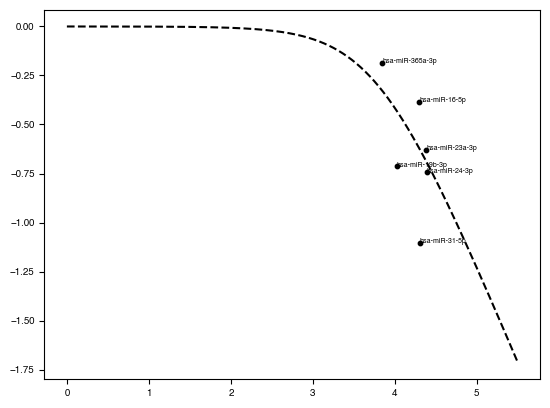

In [123]:
x_range_log = np.linspace(0, 5.5, 1000)
cell_line = "HeLa"

plt.scatter(df_expression_filter_congruence.loc[mirnas, "HeLa"], df_knockdown_filter_congruence.loc[mirnas, "HeLa"], color="black", s=10)
plt.plot(x_range_log, hill_func_log_regular(x_range_log,
                *hill_params), color="black", linewidth=1.5, label="fit", ls="--")

# label each mirna
for mirna in mirnas:
    plt.text(df_expression_filter_congruence.loc[mirna, cell_line], df_knockdown_filter_congruence.loc[mirna, cell_line], mirna, fontsize=5)

In [124]:
# redo the fitting
x_data = []
y_data = []
dataset_indices = []
for i, cell_line in enumerate(cell_lines_measured):
    ex_df = df_expression_filter_congruence.loc[mirnas, cell_line].values
    knock_df = df_knockdown_filter_congruence.loc[mirnas, cell_line].values
    x_data.append(ex_df)
    y_data.append(knock_df)
    dataset_indices.append([i] * len(ex_df))

x_data = np.concatenate(x_data)
y_data = np.concatenate(y_data)
dataset_indices = np.concatenate(dataset_indices)

# set bounds and initial guesses for non-scale fitting parameters
p0 = [3, 10]
num_params = len(p0)
bounds = ([1, 9.99], [10, 10.01])

# Guess initial scale values for all datasets
scale_guesses = [0 for _ in range(len(cell_lines_measured))]
scale_bounds_min = [-2 for _ in range(len(cell_lines_measured))]
scale_bounds_max = [2 for _ in range(len(cell_lines_measured))]

# set scale for HEK293T to 0
scale_bounds_min[0] = -0.001
scale_bounds_max[0] = 0.001

# set up parameters
p0_scale = p0 + scale_guesses
bounds_scale = (bounds[0]+scale_bounds_min, bounds[1]+scale_bounds_max)

popt_scales, pcov = popt_scales_filter, pcov = opt.curve_fit(
    lambda x, *params: hill_func_log_scales(x, dataset_indices, *params),
    x_data,
    y_data,
    p0=p0_scale,
    bounds=bounds_scale,
    maxfev=5000
)

scales = list(popt_scales[num_params:])
hill_params = popt_scales[:num_params]
hill_params

array([3.79487299, 9.99      ])

In [125]:
scale_dict_new = {cell_line: scale for cell_line, scale in zip(cell_lines_measured, scales)}

In [129]:
scale_df = pd.DataFrame.from_dict(scale_dict, orient="index", columns=["scale from whole fit"])
scale_df["scale from 6 miRNAs"] = scale_df.index.map(scale_dict_new)

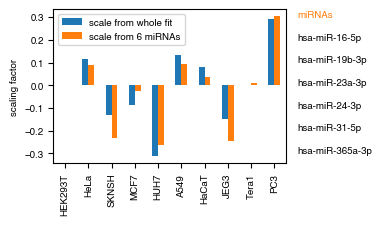

In [145]:
# plot a bargraph of the two scale dicts
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
scale_df.plot(kind="bar", ax=ax)
plt.ylabel("scaling factor")
# plot the mirnas as text to the right of the plot
ax.text(10, 0.3, "miRNAs", color="tab:orange")
for i, row in enumerate(mirnas):
    ax.text(10, 0.2 - i*0.1, row, fontsize=7)

for format in ["png", "svg"]:
    plt.savefig(f"{plot_folder}/scaling_factors.{format}", format=format, bbox_inches="tight")